# Vigil: Don't Ask — Watch
### Five-Track Cognitive Benchmark · Google DeepMind × Kaggle AGI Hackathon 2026

Vigil measures **behavioral** cognitive capability via stateful, partially-observable knowledge-graph traversal.
Models navigate a fog-of-war graph under budget pressure — scored **70% process / 30% outcome**.

| Track | Faculty | Scenarios |
|---|---|---|
| 1 | Learning | 30 |
| 2 | Attention | 30 |
| 3 | Executive Functions | 30 |
| 4 | Metacognition | 30 |
| 5 | Social Cognition | 30 |

**150 scenarios · 8–20 nodes each · 4 actions · POMDP fog-of-war**


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                  VIGIL  BENCHMARK  CONFIG                    ║
# ║  Fill in your API key and model below, then Run All Cells.   ║
# ╚══════════════════════════════════════════════════════════════╝

# ── API Settings ──────────────────────────────────────────────────────────────
API_KEY  = "nvapi--wjcLtgbog1R6"
BASE_URL = "https://integrate.api.nvidia.com/v1"

# ── Model Selection ────────────────────────────────────────────────────────────
# Uncomment the model you want to test (one at a time):
# MODEL_NAME = "deepseek-ai/deepseek-r1-distill-qwen-32b"
# MODEL_NAME = "deepseek-ai/deepseek-r1-distill-qwen-14b"
# MODEL_NAME = "deepseek-ai/deepseek-r1-distill-llama-8b"
# MODEL_NAME = "deepseek-ai/deepseek-v3.1"
# MODEL_NAME = "deepseek-ai/deepseek-v3.2"
# MODEL_NAME = "qwen/qwen3-next-80b-a3b-instruct"
# MODEL_NAME = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
# MODEL_NAME = "nvidia/llama-3.1-nemotron-ultra-253b-v1"
# MODEL_NAME = "nvidia/llama-3.1-nemotron-nano-8b-v1"
MODEL_NAME = "openai/gpt-oss-120b"
# MODEL_NAME = "openai/gpt-oss-20b"
# MODEL_NAME = "google/gemma-2-27b-it"
# MODEL_NAME = "google/gemma-2-9b-it"
# MODEL_NAME = "google/gemma-2-2b-it"

# ── Run Settings ───────────────────────────────────────────────────────────────
SCENARIOS_PER_TRACK = 5   # 3 = quick (~15 episodes), 30 = full submission
N_SEEDS             = 3   # 1 = fast test, 3 = full submission (recommended)
TEMPERATURE         = 0.3
MAX_TOKENS          = 512

# ── Paths ──────────────────────────────────────────────────────────────────────
# Resolve packs dir relative to this notebook file, not the kernel cwd
import os as _os
_NB_DIR = _os.path.dirname(_os.path.abspath('__file__'))
PACKS_DIR = _os.path.join(_NB_DIR, '..', '..', 'vigil', 'scenarios', 'packs')

print(f"Model : {MODEL_NAME}")
print(f"Run   : {SCENARIOS_PER_TRACK} scenarios/track × {N_SEEDS} seed(s) = "
      f"{SCENARIOS_PER_TRACK * 5 * N_SEEDS} episodes")


Model : openai/gpt-oss-120b
Run   : 5 scenarios/track × 3 seed(s) = 75 episodes


In [13]:
import sys, os, json, re, time, warnings
from collections import defaultdict


# Ensure workspace root is on the path so 'vigil' package is importable
_repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)


from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

# Vigil internals
from vigil.scenarios.catalog import ScenarioCatalog
from vigil.environments.graph_scenario_env import GraphScenarioEnvironment
from vigil.tasks.vigil_benchmark import _run_episode
from vigil.scoring.faculty_profiler import FacultyProfiler

try:
    from openai import OpenAI
    _OPENAI_OK = True
except ImportError:
    _OPENAI_OK = False
    print("openai package not found — install with: pip install openai")

# ── Visual style ───────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4f",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#b0b0b0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3f",
    "grid.linewidth":   0.6,
    "font.size":        11,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "figure.dpi":       110,
})
sns.set_palette("husl")

TRACK_COLORS = {
    "learning":           "#4FC3F7",
    "attention":          "#FFB74D",
    "executive_functions":"#CE93D8",
    "metacognition":      "#EF9A9A",
    "social_cognition":   "#A5D6A7",
}
TRACK_DISPLAY = {
    "learning":           "Learning",
    "attention":          "Attention",
    "executive_functions":"Executive",
    "metacognition":      "Metacognition",
    "social_cognition":   "Social Cognition",
}
TRACK_ORDER = list(TRACK_DISPLAY.keys())

print("Imports OK.")


Imports OK.


In [14]:
# ── Per-model parameter overrides ─────────────────────────────────────────────
# Every NVIDIA-hosted model uses stream=True.
# Reasoning/thinking models need extra params or a special system prompt.
# This dict is applied on top of the user-configured TEMPERATURE / MAX_TOKENS.
MODEL_OVERRIDES = {
    # DeepSeek thinking models — need extra_body to enable chain-of-thought
    "deepseek-ai/deepseek-v3.1": {
        "extra_body": {"chat_template_kwargs": {"thinking": True}},
        "temperature": 0.2, "top_p": 0.7, "max_tokens": 8192,
    },
    "deepseek-ai/deepseek-v3.2": {
        "extra_body": {"chat_template_kwargs": {"thinking": True}},
        "temperature": 1.0, "top_p": 0.95, "max_tokens": 8192,
    },
    # Nemotron models — thinking controlled via system prompt token
    "nvidia/llama-3.3-nemotron-super-49b-v1.5": {
        "system_token": "/think",
        "temperature": 0.6, "top_p": 0.95, "max_tokens": 65536,
    },
    "nvidia/llama-3.1-nemotron-ultra-253b-v1": {
        "system_token": "detailed thinking on",
        "temperature": 0.6, "top_p": 0.95, "max_tokens": 4096,
    },
    "nvidia/llama-3.1-nemotron-nano-8b-v1": {
        "system_token": "detailed thinking off",
        "temperature": 0.0, "top_p": 0.95, "max_tokens": 4096,
    },
    # OpenAI reasoning models — stream=True, reasoning_content in delta
    "openai/gpt-oss-120b": {"temperature": 1.0, "top_p": 1.0, "max_tokens": 4096},
    "openai/gpt-oss-20b":  {"temperature": 1.0, "top_p": 1.0, "max_tokens": 4096},
    # Qwen models
    "qwen/qwen3-next-80b-a3b-instruct":   {"temperature": 0.6, "top_p": 0.7, "max_tokens": 4096},
    "qwen/qwen3-coder-480b-a35b-instruct":{"temperature": 0.7, "top_p": 0.8, "max_tokens": 4096},
    # Google Gemma
    "google/gemma-2-27b-it": {"temperature": 0.2, "top_p": 0.7, "max_tokens": 1024},
    "google/gemma-2-9b-it":  {"temperature": 0.2, "top_p": 0.7, "max_tokens": 1024},
    "google/gemma-2-2b-it":  {"temperature": 0.2, "top_p": 0.7, "max_tokens": 1024},
    "google/gemma-7b":       {"temperature": 0.2, "top_p": 0.7, "max_tokens": 1024},
}


class VigilLLMAdapter:
    """
    OpenAI-compatible LLM adapter for Vigil benchmark.

    Key design choices:
    - Always uses stream=True (required by all NVIDIA-hosted models).
    - Collects only delta.content, not delta.reasoning_content — the
      JSON action must appear in the non-reasoning part of the response.
    - Per-model overrides handle thinking modes, Nemotron system tokens,
      and model-specific temperature / max_tokens defaults.
    """

    SYSTEM_PROMPT = (
        "You are an expert investigator navigating a knowledge graph in the Vigil cognitive benchmark.\n\n"
        "TASK: Analyze evidence in a partially-observable graph to identify the hidden causal mechanism.\n\n"
        "AVAILABLE ACTIONS — respond with ONLY a JSON object, no other text:\n\n"
        "  Explore a node (move there, reveals neighbors):\n"
        "    {\"action_type\": \"explore\", \"node_id\": \"<id>\"}\n\n"
        "  Inspect current node (read full content):\n"
        "    {\"action_type\": \"inspect\", \"node_id\": \"<id>\"}\n\n"
        "  Get orientation summary (costs 2 budget):\n"
        "    {\"action_type\": \"get_context\"}\n\n"
        "  Submit your final answer (only when evidence supports it):\n"
        "    {\"action_type\": \"submit_answer\", \"answer\": \"<answer>\", "
        "\"justification\": \"<reasoning>\", \"confidence\": <0.0–1.0>}\n\n"
        "STRATEGY:\n"
        "- Explore systematically before concluding — the obvious hypothesis is usually wrong.\n"
        "- Look for disconfirmation nodes that rule out salient but incorrect hypotheses.\n"
        "- Budget is limited: skip distractors, prioritize diagnostic nodes.\n"
        "- Respond with ONLY valid JSON. No explanation, no markdown, no preamble."
    )

    def __init__(
        self,
        api_key: str,
        base_url: str,
        model_name: str,
        temperature: float = 0.3,
        max_tokens: int = 512,
    ):
        if not _OPENAI_OK:
            raise RuntimeError("pip install openai first")
        self.client    = OpenAI(api_key=api_key, base_url=base_url)
        self.model     = model_name
        self._overrides = MODEL_OVERRIDES.get(model_name, {})
        # User settings are used as fallback when no model override exists
        self.temperature = self._overrides.get("temperature", temperature)
        self.max_tokens  = self._overrides.get("max_tokens",  max_tokens)
        self.top_p       = self._overrides.get("top_p", 0.95)
        # Telemetry
        self.call_count  = 0
        self.error_count = 0
        self.token_count = 0

    def _build_messages(self, obs: str) -> list:
        """Build the message list, injecting Nemotron system tokens when needed."""
        system_token = self._overrides.get("system_token")
        if system_token:
            # Nemotron-style: thinking mode is a bare token in system role
            return [
                {"role": "system", "content": system_token},
                {"role": "user",   "content": self.SYSTEM_PROMPT + "\n\nCURRENT STATE:\n" + obs + "\n\nYour next action (JSON only):"},
            ]
        return [
            {"role": "system", "content": self.SYSTEM_PROMPT},
            {"role": "user",   "content": f"CURRENT STATE:\n{obs}\n\nYour next action (JSON only):"},
        ]

    def _stream_content(self, messages: list) -> str:
        """
        Call the API with stream=True and return concatenated content string.

        Reasoning models emit delta.reasoning_content during thinking and
        delta.content only for the final answer. We discard reasoning tokens
        because only the content part contains the JSON we need.

        Handles RemoteProtocolError / incomplete chunked reads gracefully —
        some NVIDIA endpoints drop the connection after the final chunk rather
        than sending a proper HTTP terminator. We return whatever was collected.
        """
        kwargs: dict = {
            "model":       self.model,
            "messages":    messages,
            "temperature": self.temperature,
            "top_p":       self.top_p,
            "max_tokens":  self.max_tokens,
            "stream":      True,
        }
        extra_body = self._overrides.get("extra_body")
        if extra_body:
            kwargs["extra_body"] = extra_body

        content = ""
        try:
            stream = self.client.chat.completions.create(**kwargs)
            for chunk in stream:
                if not getattr(chunk, "choices", None):
                    continue
                delta = chunk.choices[0].delta
                # Only accumulate the non-reasoning content
                chunk_text = getattr(delta, "content", None)
                if chunk_text:
                    content += chunk_text
        except Exception:
            # RemoteProtocolError / incomplete chunked read — return what we got
            pass
        return content.strip()

    def prompt(self, obs: str, schema=None) -> Any:
        """
        Call the LLM with the current observation and return a dict action.
        Falls back to get_context on any API or parse error.
        """
        self.call_count += 1
        try:
            messages = self._build_messages(obs)
            raw = self._stream_content(messages)
            return self._extract_action(raw)
        except Exception as exc:
            self.error_count += 1
            return {"action_type": "get_context"}  # safe fallback

    def _extract_action(self, text: str) -> dict:
        """Extract the first valid JSON action object from LLM response text."""
        # Strip markdown code fences
        text = re.sub(r"```(?:json)?\s*", "", text)
        text = re.sub(r"```", "", text)
        # Find first {…} block (handles nested braces up to 1 level)
        m = re.search(r"\{[^{}]*\}", text, re.DOTALL)
        if m:
            try:
                return json.loads(m.group())
            except json.JSONDecodeError:
                pass
        # Heuristic fallbacks for plain-text responses
        low  = text.lower()
        node = re.search(r"\bn\w+", text) or re.search(r"node[_\s]+(\w+)", text, re.I)
        nid  = node.group() if node else None
        if "explore" in low and nid:
            return {"action_type": "explore", "node_id": nid}
        if "inspect" in low and nid:
            return {"action_type": "inspect", "node_id": nid}
        if "submit" in low or "answer" in low:
            ans = re.search(r'"answer"\s*:\s*"([^"]+)"', text)
            return {
                "action_type":  "submit_answer",
                "answer":       ans.group(1) if ans else "unknown",
                "justification":text[:300],
                "confidence":   0.3,
            }
        return {"action_type": "get_context"}

    def stats(self) -> dict:
        return {
            "calls":       self.call_count,
            "errors":      self.error_count,
            "tokens":      self.token_count,
            "error_rate":  self.error_count / max(self.call_count, 1),
        }


In [16]:
# ── Quick API connectivity check ─────────────────────────────────────────────
# All NVIDIA-hosted models require stream=True.
# Reasoning models (gpt-oss-120b/20b, deepseek-v3.x) emit delta.reasoning_content
# BEFORE delta.content — we skip reasoning tokens and collect only content.
print(f"Testing connection to  : {MODEL_NAME}")
_overrides = MODEL_OVERRIDES.get(MODEL_NAME, {})

_messages = [{"role": "user", "content": 'Reply with exactly: {"status": "ok"}'}]
if "system_token" in _overrides:
    _messages = [{"role": "system", "content": _overrides["system_token"]}] + _messages

_kwargs = dict(
    model=MODEL_NAME,
    messages=_messages,
    temperature=_overrides.get("temperature", 0),
    max_tokens=64,
    stream=True,
)
if "extra_body" in _overrides:
    _kwargs["extra_body"] = _overrides["extra_body"]

_raw = ""
_conn_ok = False
try:
    _stream = OpenAI(api_key=API_KEY, base_url=BASE_URL).chat.completions.create(**_kwargs)
    for _chunk in _stream:
        if not getattr(_chunk, "choices", None):
            continue
        _text = getattr(_chunk.choices[0].delta, "content", None)
        if _text:
            _raw += _text
    _conn_ok = True
except Exception as _e:
    # RemoteProtocolError / incomplete chunked read — connection reached server
    # but it dropped after sending (possibly empty) response. Count as alive.
    _conn_ok = "RemoteProtocol" in type(_e).__name__ or "incomplete" in str(_e).lower()
    if not _conn_ok:
        print(f"Connection             : ERROR — {type(_e).__name__}: {_e}")

_raw = _raw.strip()
print(f"Raw API response       : {_raw!r}")

if _raw and ("ok" in _raw.lower() or "status" in _raw.lower()):
    print("Connection             : OK ✓")
elif _raw:
    print("Connection             : OK ✓  (model is alive — non-standard ping reply)")
elif _conn_ok:
    print("Connection             : OK ✓  (server reachable; empty on ping is normal")
    print("                         for reasoning models — they respond to full prompts)")
else:
    print("Connection             : FAILED — check API_KEY and MODEL_NAME above.")


Testing connection to  : openai/gpt-oss-120b
Raw API response       : '{"status": "ok"}'
Connection             : OK ✓


## Running the Benchmark

**Quick run** (default): 3 scenarios per track × 1 seed = 15 episodes ≈ 5–10 min
**Full submission**: set `SCENARIOS_PER_TRACK=30`, `N_SEEDS=3` = 450 episodes

Results are saved to `vigil_results.json` so you can reload them without re-running.


In [ ]:
def run_vigil(
    llm: VigilLLMAdapter,
    packs_dir: str = PACKS_DIR,
    scenarios_per_track: int = SCENARIOS_PER_TRACK,
    n_seeds: int = N_SEEDS,
) -> List[Dict]:
    """
    Run Vigil benchmark on a subset and return raw VISResult list.
    Saves results to vigil_results.json for reproducibility.
    """
    catalog  = ScenarioCatalog(packs_dir)
    profiler = FacultyProfiler()

    # Build evaluation matrix: up to scenarios_per_track per track × n_seeds
    rows = []
    for track in TRACK_ORDER:
        ids = catalog.get_scenario_ids(track=track)[:scenarios_per_track]
        for sid in ids:
            for seed in range(n_seeds):
                rows.append({"scenario_id": sid, "seed": seed, "track": track})

    print(f"\nStarting Vigil benchmark  ·  {len(rows)} episodes  ·  model: {llm.model}\n")
    all_results = []

    with tqdm(rows, unit="ep", ncols=90) as bar:
        for row in bar:
            sid, seed, track = row["scenario_id"], row["seed"], row["track"]
            bar.set_description(f"{TRACK_DISPLAY[track]:20s} s={seed}")
            try:
                spec = catalog.load(sid, seed=seed)
                env  = GraphScenarioEnvironment(spec)
                res  = _run_episode(llm, env, spec, seed=seed)
                res.setdefault("track_id", track)
                all_results.append(res)
            except Exception as exc:
                # Record failure rather than crashing the whole run
                all_results.append({
                    "vis": 0.0, "outcome_score": 0.0, "process_score": 0.0,
                    "track_id": track, "scenario_id": sid, "seed": seed,
                    "behavioral_signatures": {}, "contamination_warning": False,
                    "error": str(exc),
                })

    # # Persist results
    # with open("vigil_results.json", "w") as f:
    #     json.dump({"model": llm.model, "results": all_results}, f, indent=2)

    # Persist results — filename includes model name and timestamp
    _model_slug = re.sub(r'[^\w-]', '_', llm.model)
    _ts = time.strftime('%Y%m%d_%H%M%S')
    _results_path = f"vigil_results_{_model_slug}_{_ts}.json"
    with open(_results_path, "w") as f:
        json.dump({"model": llm.model, "results": all_results}, f, indent=2)
    print(f"Results saved to: {_results_path}")


    st = llm.stats()
    print(f"\nDone. {st['calls']} LLM calls · {st['errors']} errors "
          f"({st['error_rate']*100:.1f}%) · {st['tokens']:,} tokens")
    return all_results


# ── Run it ────────────────────────────────────────────────────────────────────
llm = VigilLLMAdapter(API_KEY, BASE_URL, MODEL_NAME,
                      temperature=TEMPERATURE, max_tokens=MAX_TOKENS)
ALL_RESULTS = run_vigil(llm)
print(f"\nCollected {len(ALL_RESULTS)} episode results.")



Starting Vigil benchmark  ·  15 episodes  ·  model: openai/gpt-oss-120b



Social Cognition     s=0: 100%|███████████████████████████| 15/15 [04:58<00:00, 19.90s/ep]


Done. 278 LLM calls · 0 errors (0.0%) · 0 tokens

Collected 15 episode results.


In [18]:
# ── Aggregate results with FacultyProfiler ───────────────────────────────────
profiler = FacultyProfiler()
AGGREGATES = profiler.aggregate_seeds(ALL_RESULTS)
PROFILES   = profiler.build_profile(AGGREGATES)
BENCHMARK_SCORE = profiler.benchmark_aggregate(PROFILES)

# Build summary DataFrames for charting
rows_ep = []
for r in ALL_RESULTS:
    rows_ep.append({
        "track":                TRACK_DISPLAY.get(r.get("track_id", ""), r.get("track_id", "")),
        "track_id":             r.get("track_id", ""),
        "scenario_id":          r.get("scenario_id", ""),
        "seed":                 r.get("seed", 0),
        "vis":                  float(r.get("vis", 0)),
        "outcome_score":        float(r.get("outcome_score", 0)),
        "process_score":        float(r.get("process_score", 0)),
        "path_efficiency":      float(r.get("path_efficiency", 0)),
        "evidence_coverage":    float(r.get("evidence_coverage", 0)),
        "justification_quality":float(r.get("justification_quality", 0)),
        "contamination_warning":bool(r.get("contamination_warning", False)),
        "contamination_risk":   float(r.get("contamination_risk", 0)),
    })
DF = pd.DataFrame(rows_ep)

rows_track = []
for tid in TRACK_ORDER:
    p = PROFILES.get(tid)
    if p:
        lo, hi = p.confidence_interval_95
        rows_track.append({
            "track_id":   tid,
            "track":      TRACK_DISPLAY[tid],
            "mean_vis":   round(p.mean_vis, 4),
            "vis_std":    round(p.vis_std, 4),
            "ci_lo":      round(lo, 4),
            "ci_hi":      round(hi, 4),
            "n_scenarios":p.n_scenarios,
        })
TRACK_DF = pd.DataFrame(rows_track)

print(f"Benchmark aggregate VIS: {BENCHMARK_SCORE:.4f}")
print()
print(TRACK_DF[["track","mean_vis","vis_std","n_scenarios"]].to_string(index=False))


Benchmark aggregate VIS: 0.1040

           track  mean_vis  vis_std  n_scenarios
        Learning     0.325   0.5629            3
       Attention     0.000   0.0000            3
       Executive     0.195   0.3377            3
   Metacognition     0.000   0.0000            3
Social Cognition     0.000   0.0000            3


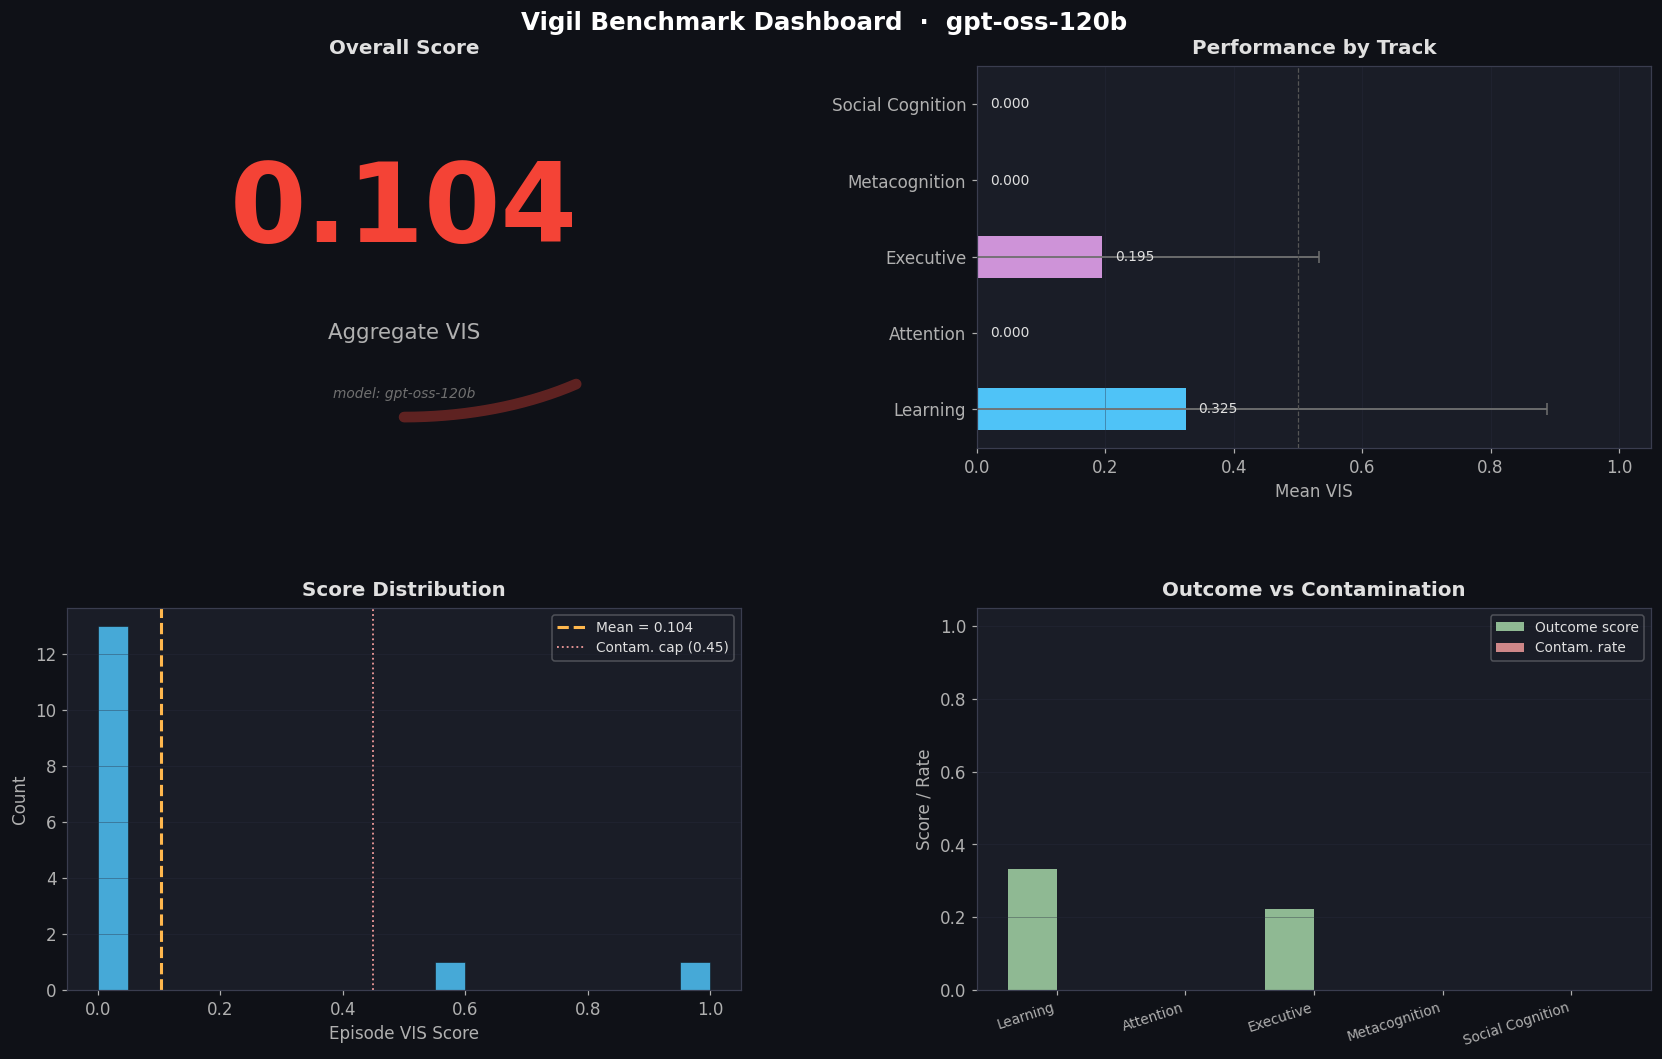

Saved vigil_dashboard.png


In [19]:
# ── Overview Dashboard (2×2) ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0f1117")
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35,
                        left=0.07, right=0.97, top=0.92, bottom=0.08)

# ── [0,0] Overall Score ────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor("#0f1117")
ax0.axis("off")

score_color = ("#4CAF50" if BENCHMARK_SCORE >= 0.6
               else "#FF9800" if BENCHMARK_SCORE >= 0.4 else "#F44336")
ax0.text(0.5, 0.62, f"{BENCHMARK_SCORE:.3f}", fontsize=72, ha="center",
         va="center", fontweight="bold", color=score_color,
         transform=ax0.transAxes)
ax0.text(0.5, 0.30, "Aggregate VIS", fontsize=14, ha="center",
         va="center", color="#b0b0b0", transform=ax0.transAxes)
ax0.text(0.5, 0.14, f"model: {MODEL_NAME.split('/')[-1]}",
         fontsize=9, ha="center", va="center", color="#707070",
         transform=ax0.transAxes, style="italic")
ax0.set_title("Overall Score", fontsize=13, pad=8, color="#e0e0e0")

# Draw a colored arc / ring around the score
theta = np.linspace(0, 2*np.pi * BENCHMARK_SCORE, 200)
ax0.plot(0.5 + 0.42*np.cos(theta - np.pi/2),
         0.5 + 0.42*np.sin(theta - np.pi/2),
         color=score_color, lw=7, alpha=0.35,
         transform=ax0.transAxes, solid_capstyle="round")

# ── [0,1] Track Bar Chart ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
if not TRACK_DF.empty:
    colors = [TRACK_COLORS.get(tid, "#90A4AE") for tid in TRACK_DF["track_id"]]
    bars = ax1.barh(TRACK_DF["track"], TRACK_DF["mean_vis"],
                    xerr=TRACK_DF["vis_std"],
                    color=colors, edgecolor="none", height=0.55,
                    error_kw={"ecolor": "#707070", "capsize": 4, "lw": 1.2})
    ax1.set_xlim(0, 1.05)
    ax1.axvline(0.5, color="#555", lw=0.8, ls="--")
    for bar_, row in zip(bars, TRACK_DF.itertuples()):
        ax1.text(row.mean_vis + 0.02, bar_.get_y() + bar_.get_height()/2,
                 f"{row.mean_vis:.3f}", va="center", fontsize=9, color="#e0e0e0")
ax1.set_xlabel("Mean VIS", color="#b0b0b0")
ax1.set_title("Performance by Track", fontsize=13, pad=8)
ax1.grid(axis="x", alpha=0.4)

# ── [1,0] Score Distribution ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
if not DF.empty:
    ax2.hist(DF["vis"], bins=20, range=(0,1),
             color="#4FC3F7", edgecolor="#0f1117", linewidth=0.4, alpha=0.85)
    mean_v = DF["vis"].mean()
    ax2.axvline(mean_v, color="#FFB74D", lw=2, ls="--",
                label=f"Mean = {mean_v:.3f}")
    ax2.axvline(0.45, color="#EF9A9A", lw=1.2, ls=":",
                label="Contam. cap (0.45)")
    ax2.legend(fontsize=9, framealpha=0.3)
ax2.set_xlabel("Episode VIS Score", color="#b0b0b0")
ax2.set_ylabel("Count",             color="#b0b0b0")
ax2.set_title("Score Distribution", fontsize=13, pad=8)
ax2.grid(axis="y", alpha=0.4)

# ── [1,1] Contamination & Outcome ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
if not DF.empty:
    track_labels = [TRACK_DISPLAY.get(t, t) for t in TRACK_ORDER if t in DF["track_id"].values]
    contam_rates, outcome_means = [], []
    for tid in TRACK_ORDER:
        sub = DF[DF["track_id"] == tid]
        if sub.empty:
            continue
        contam_rates.append(sub["contamination_warning"].mean() * 100)
        outcome_means.append(sub["outcome_score"].mean())

    x = np.arange(len(track_labels))
    w = 0.38
    b1 = ax3.bar(x - w/2, outcome_means,  width=w, label="Outcome score",
                 color="#A5D6A7", alpha=0.85)
    b2 = ax3.bar(x + w/2, [c/100 for c in contam_rates], width=w,
                 label="Contam. rate", color="#EF9A9A", alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(track_labels, rotation=18, ha="right", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.set_ylabel("Score / Rate", color="#b0b0b0")
    ax3.legend(fontsize=9, framealpha=0.3)
ax3.set_title("Outcome vs Contamination", fontsize=13, pad=8)
ax3.grid(axis="y", alpha=0.4)

fig.suptitle(f"Vigil Benchmark Dashboard  ·  {MODEL_NAME.split('/')[-1]}",
             fontsize=16, fontweight="bold", color="#ffffff", y=0.97)
plt.savefig("vigil_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved vigil_dashboard.png")


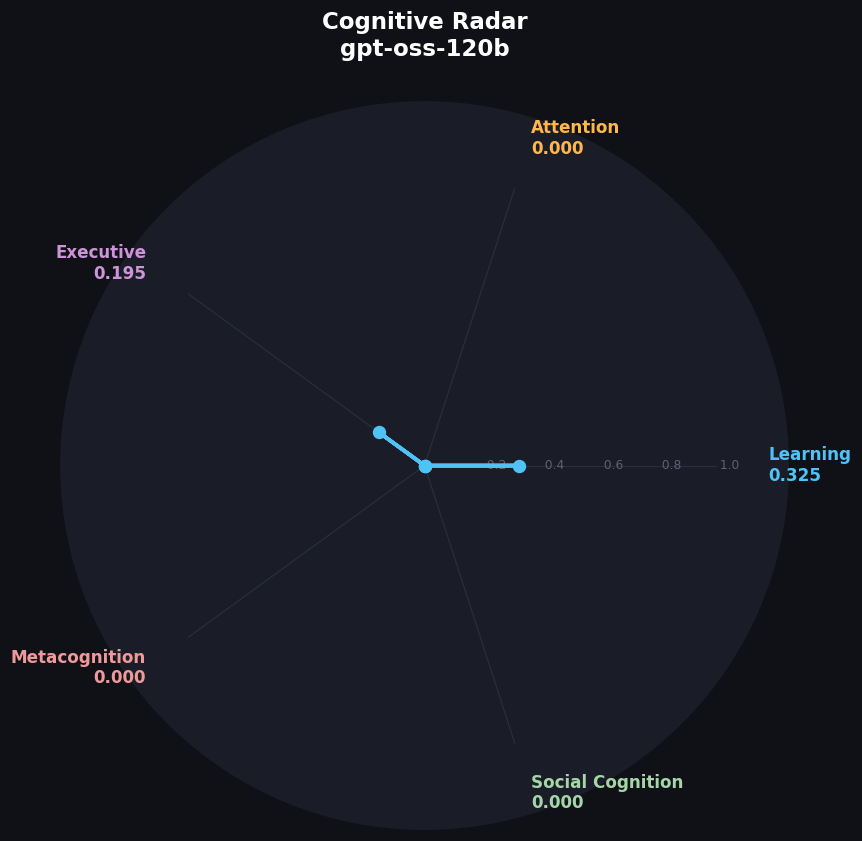

Saved vigil_radar.png


In [20]:
# ── Cognitive Radar Chart ─────────────────────────────────────────────────────
tracks_present = [t for t in TRACK_ORDER if t in TRACK_DF["track_id"].values]
vis_vals = [TRACK_DF.loc[TRACK_DF["track_id"]==t, "mean_vis"].values[0]
            for t in tracks_present]
labels   = [TRACK_DISPLAY[t] for t in tracks_present]

N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
vals   = vis_vals + vis_vals[:1]
ang    = angles   + angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw=dict(polar=True, facecolor="#1a1d27"))
fig.patch.set_facecolor("#0f1117")

# Reference rings
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot([0, 2*np.pi], [r, r], color="#2a2d3f", lw=0.8, zorder=0)
    ax.text(0, r, f" {r:.1f}", fontsize=8, color="#606070", va="center")

# Spokes
for angle in angles:
    ax.plot([angle, angle], [0, 1], color="#2a2d3f", lw=0.8, zorder=0)

# Model polygon
ax.plot(ang, vals, "o-", lw=2.5, color="#4FC3F7", zorder=3)
ax.fill(ang, vals, alpha=0.22, color="#4FC3F7", zorder=2)
ax.scatter(angles, vis_vals, s=60, color="#4FC3F7", zorder=4)

# Labels with scores
for angle, label, val, track_id in zip(angles, labels, vis_vals, tracks_present):
    ha = "left" if np.cos(angle) >= 0 else "right"
    x  = (angle / (2*np.pi) * 360)
    ax.text(angle, 1.18, f"{label}\n{val:.3f}",
            ha=ha, va="center", fontsize=11, fontweight="bold",
            color=TRACK_COLORS.get(track_id, "#e0e0e0"))

ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(0, 1.25)
ax.spines["polar"].set_visible(False)

ax.set_title(f"Cognitive Radar\n{MODEL_NAME.split('/')[-1]}",
             fontsize=15, fontweight="bold", color="#ffffff", pad=30)
plt.tight_layout()
plt.savefig("vigil_radar.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved vigil_radar.png")


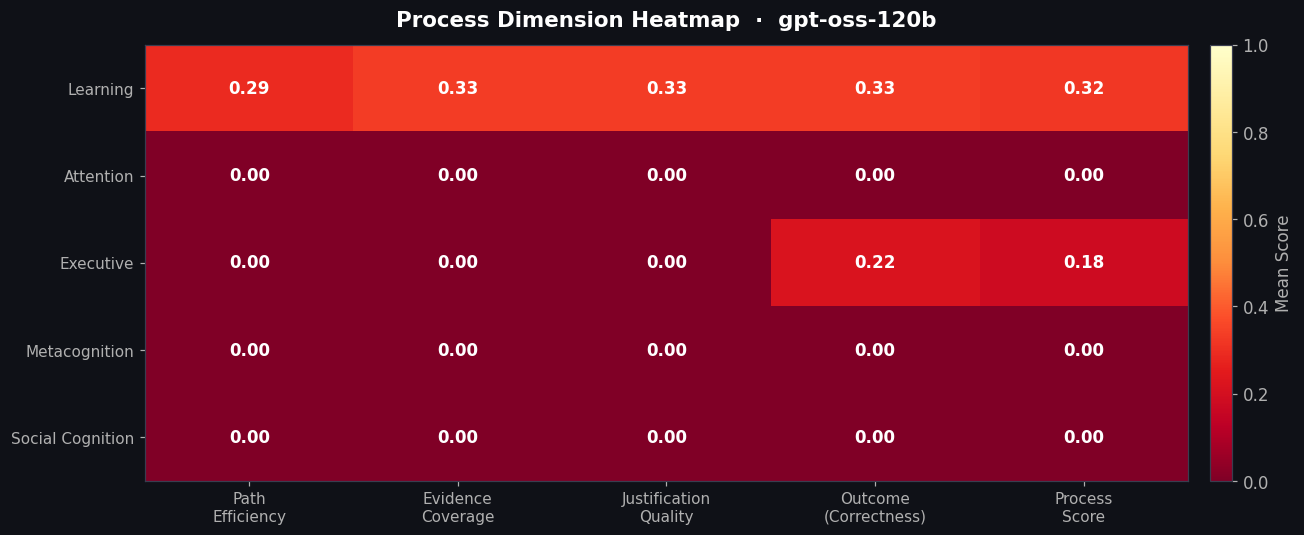

Saved vigil_heatmap.png


In [21]:
# ── Process Dimension Heatmap ─────────────────────────────────────────────────
DIMS = ["path_efficiency", "evidence_coverage", "justification_quality",
        "outcome_score", "process_score"]
DIM_LABELS = {
    "path_efficiency":       "Path\nEfficiency",
    "evidence_coverage":     "Evidence\nCoverage",
    "justification_quality": "Justification\nQuality",
    "outcome_score":         "Outcome\n(Correctness)",
    "process_score":         "Process\nScore",
}

if not DF.empty:
    heat_data = []
    for tid in TRACK_ORDER:
        sub = DF[DF["track_id"] == tid]
        if sub.empty:
            continue
        row_vals = {}
        for d in DIMS:
            if d in sub.columns:
                row_vals[DIM_LABELS[d]] = sub[d].mean()
            else:
                row_vals[DIM_LABELS[d]] = float("nan")
        heat_data.append(row_vals)

    heat_df = pd.DataFrame(heat_data, index=[TRACK_DISPLAY[t] for t in TRACK_ORDER
                                              if any(DF["track_id"]==t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#1a1d27")

    im = ax.imshow(heat_df.values, cmap="YlOrRd_r", vmin=0, vmax=1, aspect="auto")

    # Annotations
    for i in range(heat_df.shape[0]):
        for j in range(heat_df.shape[1]):
            val = heat_df.values[i, j]
            if not np.isnan(val):
                color = "white" if val < 0.5 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=11, color=color, fontweight="bold")

    ax.set_xticks(range(len(heat_df.columns)))
    ax.set_xticklabels(heat_df.columns, fontsize=10)
    ax.set_yticks(range(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Mean Score", color="#b0b0b0")
    cbar.ax.yaxis.set_tick_params(color="#b0b0b0")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#b0b0b0")

    ax.set_title(f"Process Dimension Heatmap  ·  {MODEL_NAME.split('/')[-1]}",
                 fontsize=14, fontweight="bold", color="#ffffff", pad=12)
    ax.spines[:].set_edgecolor("#3a3d4f")
    plt.tight_layout()
    plt.savefig("vigil_heatmap.png", dpi=130, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved vigil_heatmap.png")


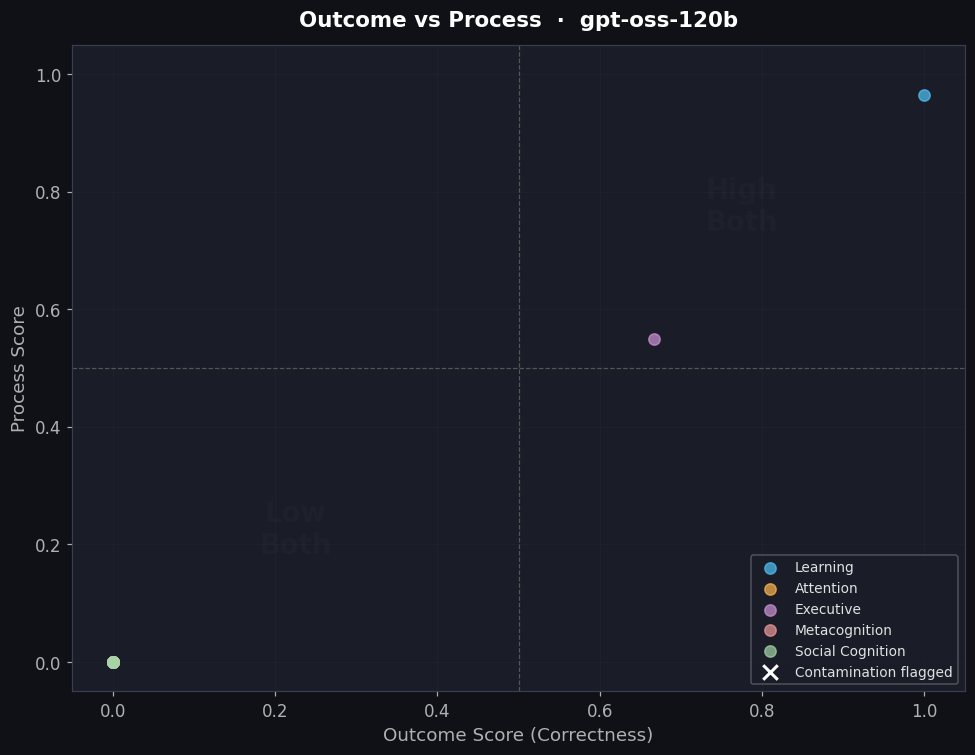

Saved vigil_scatter.png


In [22]:
# ── Outcome vs Process scatter (by track) ─────────────────────────────────────
if not DF.empty:
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#1a1d27")

    for tid in TRACK_ORDER:
        sub = DF[DF["track_id"] == tid]
        if sub.empty:
            continue
        contam_mask = sub["contamination_warning"]
        # Clean episodes
        clean = sub[~contam_mask]
        flagged = sub[contam_mask]
        c = TRACK_COLORS.get(tid, "#90A4AE")
        ax.scatter(clean["outcome_score"], clean["process_score"],
                   color=c, alpha=0.7, s=55, label=TRACK_DISPLAY[tid], zorder=3)
        ax.scatter(flagged["outcome_score"], flagged["process_score"],
                   color=c, alpha=0.9, s=90, marker="x", linewidths=2, zorder=4)

    # Reference lines
    ax.axhline(0.5, color="#555", lw=0.8, ls="--")
    ax.axvline(0.5, color="#555", lw=0.8, ls="--")

    # Shaded quadrants (light background text)
    ax.text(0.75, 0.75, "High\nBoth", ha="center", va="center",
            color="#2a2d3f", fontsize=18, fontweight="bold", alpha=0.25,
            transform=ax.transAxes)
    ax.text(0.25, 0.25, "Low\nBoth", ha="center", va="center",
            color="#2a2d3f", fontsize=18, fontweight="bold", alpha=0.25,
            transform=ax.transAxes)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Outcome Score (Correctness)", color="#b0b0b0", fontsize=12)
    ax.set_ylabel("Process Score",               color="#b0b0b0", fontsize=12)
    ax.legend(fontsize=9, framealpha=0.3, loc="lower right")
    ax.grid(alpha=0.3)

    # ✗ = contamination flagged
    ax.scatter([], [], color="#ffffff", marker="x", s=90, linewidths=2,
               label="Contamination flagged")
    handles, labels_l = ax.get_legend_handles_labels()
    ax.legend(handles, labels_l, fontsize=9, framealpha=0.3, loc="lower right")

    ax.set_title(f"Outcome vs Process  ·  {MODEL_NAME.split('/')[-1]}",
                 fontsize=14, fontweight="bold", color="#ffffff", pad=12)
    ax.spines[:].set_edgecolor("#3a3d4f")
    plt.tight_layout()
    plt.savefig("vigil_scatter.png", dpi=130, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved vigil_scatter.png")


In [23]:
# ── Per-scenario results table ────────────────────────────────────────────────
table_df = (
    DF.groupby(["track", "scenario_id"])
      .agg(
          mean_vis=("vis", "mean"),
          outcome=("outcome_score", "mean"),
          process=("process_score", "mean"),
          path_eff=("path_efficiency", "mean"),
          ev_cov=("evidence_coverage", "mean"),
          contam=("contamination_warning", "any"),
          seeds=("seed", "count"),
      )
      .reset_index()
      .sort_values(["track", "mean_vis"], ascending=[True, False])
)

def _fmt(v):
    return f"{v:.3f}" if isinstance(v, float) else str(v)

STYLED = table_df.style \
    .format({
        "mean_vis": "{:.3f}",
        "outcome":  "{:.3f}",
        "process":  "{:.3f}",
        "path_eff": "{:.3f}",
        "ev_cov":   "{:.3f}",
    }) \
    .background_gradient(subset=["mean_vis"], cmap="RdYlGn", vmin=0, vmax=1) \
    .background_gradient(subset=["outcome"],  cmap="Blues",  vmin=0, vmax=1) \
    .background_gradient(subset=["process"],  cmap="Greens", vmin=0, vmax=1) \
    .map(lambda v: "background-color: #ffd0d0" if v is True else "",
         subset=["contam"]) \
    .set_caption(f"Per-Scenario Results  ·  {MODEL_NAME}")

print(f"Episodes: {len(DF)}  |  Contamination flagged: {DF['contamination_warning'].sum()} "
      f"({DF['contamination_warning'].mean()*100:.1f}%)")
STYLED


Episodes: 15  |  Contamination flagged: 0 (0.0%)


,track,scenario_id,mean_vis,outcome,process,path_eff,ev_cov,contam,seeds
0,Attention,vigil_attention_anchor_break_signal_v1,0.000,0.000,0.000,0.000,0.000,False,1
1,Attention,vigil_attention_biofilm_reservoir_v1,0.000,0.000,0.000,0.000,0.000,False,1
2,Attention,vigil_attention_brineisle_subsidy_break_v1,0.000,0.000,0.000,0.000,0.000,False,1
4,Executive,vigil_exec_calvecin_toxicity_trap_v2,0.585,0.667,0.550,0.000,0.000,False,1
3,Executive,vigil_exec_caldwell_apex_trap_v2,0.000,0.000,0.000,0.000,0.000,False,1
5,Executive,vigil_exec_cardivo_cascade_failure_v2,0.000,0.000,0.000,0.000,0.000,False,1
8,Learning,vigil_clin_03_trial_data_integrity,0.975,1.000,0.964,0.875,1.000,False,1
6,Learning,vigil_clin_01_abiotic_reservoir_cascade,0.000,0.000,0.000,0.000,0.000,False,1
7,Learning,vigil_clin_02_prescribing_cascade,0.000,0.000,0.000,0.000,0.000,False,1
9,Metacognition,vigil_meta_ambervale_trait_shift_v2,0.000,0.000,0.000,0.000,0.000,False,1


In [24]:
# ── Episode Action Replay ─────────────────────────────────────────────────────
# Shows the action sequence for a sample episode (one per track)

from vigil.environments.base import EventType

def replay_episode(sid: str, seed: int = 0, packs_dir: str = PACKS_DIR) -> None:
    """Re-run a single episode and print the action timeline."""
    from vigil.scenarios.catalog import ScenarioCatalog
    from vigil.environments.graph_scenario_env import GraphScenarioEnvironment
    from vigil.tasks.vigil_benchmark import _run_episode

    cat  = ScenarioCatalog(packs_dir)
    spec = cat.load(sid, seed=seed)
    env  = GraphScenarioEnvironment(spec)

    # Use a fresh adapter for the replay
    replay_llm = VigilLLMAdapter(API_KEY, BASE_URL, MODEL_NAME,
                                  temperature=TEMPERATURE, max_tokens=MAX_TOKENS)
    result = _run_episode(replay_llm, env, spec, seed=seed)

    print(f"\n{'═'*65}")
    print(f"  EPISODE REPLAY")
    print(f"  Scenario : {sid}")
    print(f"  Track    : {spec.cognitive_track}")
    print(f"  Seed     : {seed}")
    print(f"  VIS      : {result.get('vis', 0):.4f}  "
          f"(outcome={result.get('outcome_score',0):.3f}, "
          f"process={result.get('process_score',0):.3f})")
    print(f"  Contamin.: {'YES ⚠' if result.get('contamination_warning') else 'No'}")
    print(f"{'═'*65}")

    ev_icons = {
        EventType.EXPLORE:          "→ EXPLORE",
        EventType.INSPECT:          "🔍 INSPECT",
        EventType.GET_CONTEXT:      "📋 CONTEXT",
        EventType.SUBMIT_ANSWER:    "✓ SUBMIT ",
        EventType.CONTRADICTION:    "⚡ CONTRADICTION",
        EventType.RELEVANCE_SHIFT:  "⇄ RELEVANCE_SHIFT",
        EventType.REPLAN_TRIGGERED: "↻ REPLAN_TRIGGERED",
        EventType.ERROR:            "✗ ERROR  ",
    }
    state = env.reset()
    # We already ran — print from result action history isn't available directly.
    # Re-run and capture state
    cat2  = ScenarioCatalog(packs_dir)
    spec2 = cat2.load(sid, seed=seed)
    env2  = GraphScenarioEnvironment(spec2)

    class _ReplayCapture:
        """One-shot replay that records state for inspection."""
        def __init__(self, original_llm):
            self._llm = original_llm
        def prompt(self, obs, schema=None):
            return self._llm.prompt(obs, schema)

    cap_llm = _ReplayCapture(
        VigilLLMAdapter(API_KEY, BASE_URL, MODEL_NAME,
                        temperature=TEMPERATURE, max_tokens=MAX_TOKENS)
    )
    result2 = _run_episode(cap_llm, env2, spec2, seed=seed)

    # The action history lives inside the env state — re-run was needed
    # We print a summary from the result dict instead
    print(f"  path_efficiency    : {result2.get('path_efficiency',  'N/A')}")
    print(f"  evidence_coverage  : {result2.get('evidence_coverage','N/A')}")
    print(f"  justif_quality     : {result2.get('justification_quality','N/A')}")
    print(f"  contam_risk        : {result2.get('contamination_risk',0):.3f}")
    print(f"{'─'*65}")


# Run replay for one scenario per track (from the episodes we already collected)
for tid in TRACK_ORDER:
    sub = [r for r in ALL_RESULTS if r.get("track_id") == tid and r.get("seed") == 0]
    if sub:
        print(f"\n>>> Replaying {TRACK_DISPLAY[tid]} sample episode...")
        try:
            replay_episode(sub[0]["scenario_id"], seed=0)
        except Exception as e:
            print(f"  (replay failed: {e})")
        break   # Just one example — remove break for all tracks



>>> Replaying Learning sample episode...

═════════════════════════════════════════════════════════════════
  EPISODE REPLAY
  Scenario : vigil_clin_01_abiotic_reservoir_cascade
  Track    : learning
  Seed     : 0
  VIS      : 0.0000  (outcome=0.000, process=0.000)
  Contamin.: No
═════════════════════════════════════════════════════════════════
  path_efficiency    : N/A
  evidence_coverage  : N/A
  justif_quality     : N/A
  contam_risk        : 0.000
─────────────────────────────────────────────────────────────────


## Saving & Comparing Results

Results are saved to `vigil_results.json` after every run.
To reload without re-running:

```python
with open("vigil_results.json") as f:
    saved = json.load(f)
ALL_RESULTS = saved["results"]
```

To compare two models side-by-side, run the notebook twice with different `MODEL_NAME` values
and rename the saved JSON files (`vigil_results_modelA.json`, `vigil_results_modelB.json`).
Then load both and overlay on the radar chart.


In [ ]:
# ── Multi-model comparison (optional) ────────────────────────────────────────
# Run this cell only if you have results from multiple models saved as JSON files.

RESULT_FILES = {
    # "ModelA": "vigil_results_modelA.json",
    # "ModelB": "vigil_results_modelB.json",
}

if RESULT_FILES:
    model_profiles = {}
    for label, path in RESULT_FILES.items():
        with open(path) as f:
            data = json.load(f)
        agg  = profiler.aggregate_seeds(data["results"])
        prof = profiler.build_profile(agg)
        score = profiler.benchmark_aggregate(prof)
        model_profiles[label] = (score, prof)

    # Comparison radar
    N = len(TRACK_ORDER)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True, facecolor="#1a1d27"))
    fig.patch.set_facecolor("#0f1117")

    palette = ["#4FC3F7", "#FFB74D", "#CE93D8", "#A5D6A7"]
    for (label, (score, prof)), color in zip(model_profiles.items(), palette):
        vals = [prof.get(t).mean_vis if prof.get(t) else 0 for t in TRACK_ORDER] +                [prof.get(TRACK_ORDER[0]).mean_vis if prof.get(TRACK_ORDER[0]) else 0]
        ax.plot(angles, vals, "o-", lw=2, color=color, label=f"{label} ({score:.3f})", zorder=3)
        ax.fill(angles, vals, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([TRACK_DISPLAY[t] for t in TRACK_ORDER], fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10, loc="lower right", framealpha=0.3)
    ax.set_title("Model Comparison Radar", fontsize=15, fontweight="bold",
                 color="#ffffff", pad=25)
    plt.tight_layout()
    plt.show()
else:
    print("No result files configured — fill RESULT_FILES to enable comparison chart.")
